# QAOA performance vs overlap with the X-mixer ground state

In [1]:
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np

from qiskit import QuantumCircuit, QuantumRegister

from qaoa import QAOA, problems, mixers, initialstates

## Custom initial state

In [2]:
class TiltedProductState(initialstates.InitialState):
    def __init__(self, theta):
        super().__init__(label=f"Tilted(theta={theta:.3f})")
        self.theta = float(theta)

    def create_circuit(self):
        q = QuantumRegister(self.N_qubits)
        self.circuit = QuantumCircuit(q)
        for i in range(self.N_qubits):
            self.circuit.ry(self.theta, q[i])

## Helper functions

In [3]:
def overlap_with_x_ground_state(theta, n_qubits):
    return float(((1.0 + np.sin(theta)) / 2.0) ** n_qubits)

## Choose a graph instance

Keep the graph small enough that we can compute the exact optimum classically.

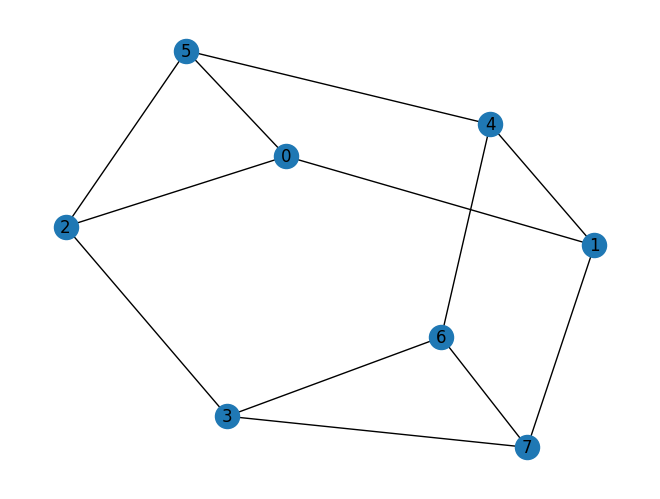

In [4]:
seed = 42
G = nx.random_regular_graph(d=3, n=8, seed=seed)

pos = nx.spring_layout(G, seed=seed)
nx.draw(G, pos=pos, with_labels=True)

In [5]:
problem = problems.MaxCut(G)
mincost, maxcost = problem.computeMinMaxCosts()

## Sweep the overlap

We scan `theta` in `[0, pi]`, compute the overlap with the X-mixer ground state, and optimize QAOA for several depths.

In [6]:
depth=5
numpoints=8

thetas = np.linspace(0.0, np.pi/2, 8)

overlaps = [overlap_with_x_ground_state(theta, problem.N_qubits) for theta in thetas]

qaoa = []
for theta in thetas:
    print(theta)
    tmp = QAOA(initialstate=TiltedProductState(theta), problem=problem, mixer=mixers.X())
    tmp.sample_cost_landscape(angles={"gamma": [0, 2*np.pi , 50], "beta": [0, 2*np.pi, 50]})
    tmp.optimize(depth=depth)
    qaoa.append(tmp)

0.0
2026-03-13 11:20:48 [info     ] Calculating energy landscape for depth p=1... file=qaoa.qaoa func=sample_cost_landscape
2026-03-13 11:20:48 [info     ] Executing sample_cost_landscape file=qaoa.qaoa func=sample_cost_landscape
2026-03-13 11:20:48 [info     ] circuits: 2500                 file=qaoa.qaoa func=sample_cost_landscape
2026-03-13 11:20:48 [info     ] Done execute                   file=qaoa.qaoa func=sample_cost_landscape
2026-03-13 11:21:02 [info     ] Done measurement               file=qaoa.qaoa func=sample_cost_landscape
2026-03-13 11:21:02 [info     ] Calculating Energy landscape done file=qaoa.qaoa func=sample_cost_landscape
2026-03-13 11:21:03 [info     ] cost(depth 1 = -6.0957031250000036 file=qaoa.qaoa func=optimize
2026-03-13 11:21:04 [info     ] cost(depth 2 = -7.258789062500001 file=qaoa.qaoa func=optimize
2026-03-13 11:21:05 [info     ] cost(depth 3 = -7.244140625000002 file=qaoa.qaoa func=optimize
2026-03-13 11:21:06 [info     ] cost(depth 4 = -7.36230468749

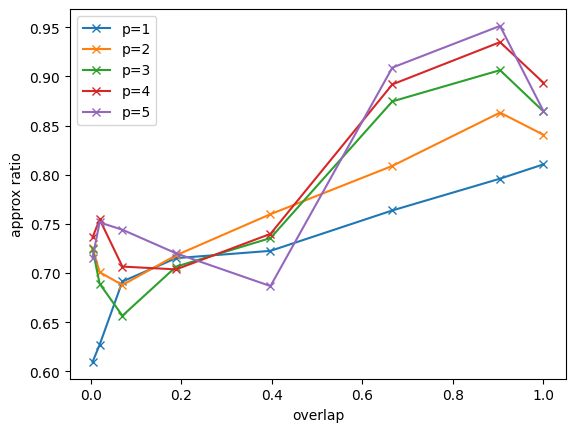

In [7]:
for i in range(depth):
    exp=[]
    for j in range (numpoints):
        # Normalized approximation ratio for a minimization objective.
        # Here mincost is the optimal (most negative) value and maxcost the worst.
        # This maps exp = maxcost → 0 (worst) and exp = mincost → 1 (optimal).
        # Hence we use (maxcost - exp) / (maxcost - mincost).
        exp.append((maxcost - qaoa[j].get_Exp()[i] )/(maxcost-mincost))
    plt.plot(overlaps,exp,label="p="+str(i+1),marker='x')

plt.xlabel("overlap")
plt.ylabel("approx ratio")
plt.legend()

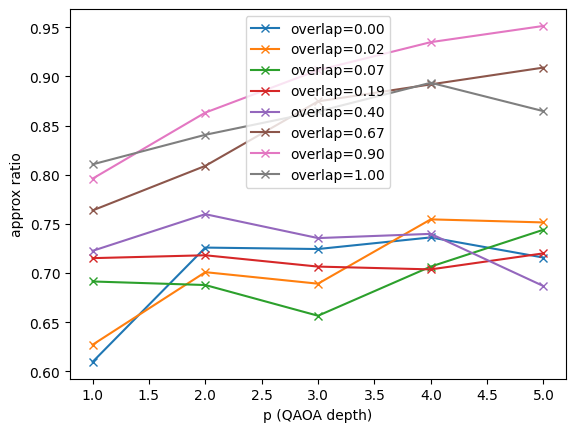

In [8]:
depths = range(1, depth+1)

for j in range(numpoints):
    exp = []
    for i in range(depth):
        # Normalized approximation ratio for a minimization objective
        exp.append((maxcost - qaoa[j].get_Exp()[i]) / (maxcost - mincost))

    plt.plot(depths, exp, label=f"overlap={overlaps[j]:.2f}", marker='x')

plt.xlabel("p (QAOA depth)")
plt.ylabel("approx ratio")
plt.legend()